# Text Generation using RNN, LSTM and GRU
This notebook trains a Simple RNN, an LSTM and a GRU on the same text data and compares their next word prediction quality.

## Problem Statement
Build a next word prediction model using RNN, LSTM and GRU and compare their training loss and generated text.

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt

print("tensorflow version:", tf.__version__)

tensorflow version: 2.21.0


## Load Text Corpus
A slightly longer paragraph is used so the models have enough context to learn from.

In [2]:
corpus = '''
deep learning is one of the most exciting fields in ai right now
i have been learning about neural networks for the past few weeks
recurrent neural networks are used when the data has some order like text
lstm and gru are both types of recurrent networks
lstm has more gates than gru so it takes longer to train
i think gru is a good starting point before moving to lstm
neural networks need a lot of data to perform well
text generation is one of the coolest applications of these models
predicting the next word in a sentence is harder than it looks
this assignment helped me understand rnn lstm and gru a little better
'''
print(corpus)


deep learning is one of the most exciting fields in ai right now
i have been learning about neural networks for the past few weeks
recurrent neural networks are used when the data has some order like text
lstm and gru are both types of recurrent networks
lstm has more gates than gru so it takes longer to train
i think gru is a good starting point before moving to lstm
neural networks need a lot of data to perform well
text generation is one of the coolest applications of these models
predicting the next word in a sentence is harder than it looks
this assignment helped me understand rnn lstm and gru a little better



## Tokenization and Sequence Creation
The text is converted into integer tokens, then split into input and target word sequences for next word prediction.

In [3]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("vocabulary size:", total_words)

input_sequences = []
for line in corpus.split("\n"):
    if line.strip() == "":
        continue
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding="pre")

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

vocabulary size: 78
X shape: (106, 12)
y shape: (106,)


## Train Validation Split
A small validation split is kept aside to check if the models are actually learning and not just memorizing.

In [4]:
num_samples = X.shape[0]
split_index = int(num_samples * 0.85)

# shuffle before splitting so the validation set is not just the last few lines
indices = np.arange(num_samples)
np.random.seed(42)
np.random.shuffle(indices)

X = X[indices]
y = y[indices]

X_train, X_val = X[:split_index], X[split_index:]
y_train, y_val = y[:split_index], y[split_index:]

print("train samples:", X_train.shape[0])
print("val samples:", X_val.shape[0])

train samples: 90
val samples: 16


## Model 1: Vanilla RNN
This is the baseline model. It usually struggles with long term dependencies.

In [5]:
rnn_model = Sequential([
    Embedding(total_words, 64),
    SimpleRNN(128),
    Dense(total_words, activation="softmax")
])

rnn_model.compile(loss="sparse_categorical_crossentropy",
                   optimizer="adam",
                   metrics=["accuracy"])

rnn_history = rnn_model.fit(X_train, y_train,
                             validation_data=(X_val, y_val),
                             epochs=200, verbose=0)

print("rnn training completed")
print("rnn param count:", rnn_model.count_params())

rnn training completed
rnn param count: 39758


## Model 2: LSTM
LSTM uses input, forget and output gates to keep long term memory.

In [6]:
lstm_model = Sequential([
    Embedding(total_words, 64),
    LSTM(128),
    Dense(total_words, activation="softmax")
])

lstm_model.compile(loss="sparse_categorical_crossentropy",
                    optimizer="adam",
                    metrics=["accuracy"])

lstm_history = lstm_model.fit(X_train, y_train,
                               validation_data=(X_val, y_val),
                               epochs=200, verbose=0)

print("lstm training completed")
print("lstm param count:", lstm_model.count_params())

lstm training completed
lstm param count: 113870


## Model 3: GRU
GRU uses only an update gate and a reset gate, so it trains faster than LSTM.

In [7]:
gru_model = Sequential([
    Embedding(total_words, 64),
    GRU(128),
    Dense(total_words, activation="softmax")
])

gru_model.compile(loss="sparse_categorical_crossentropy",
                   optimizer="adam",
                   metrics=["accuracy"])

gru_history = gru_model.fit(X_train, y_train,
                             validation_data=(X_val, y_val),
                             epochs=200, verbose=0)

print("gru training completed")
print("gru param count:", gru_model.count_params())

gru training completed
gru param count: 89550


## Compare Training and Validation Loss
Plotting the loss curves shows which model fits the data best and which one overfits the most.

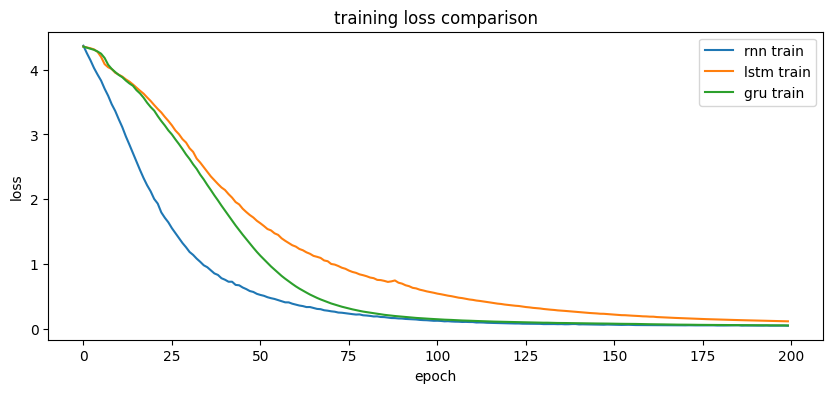

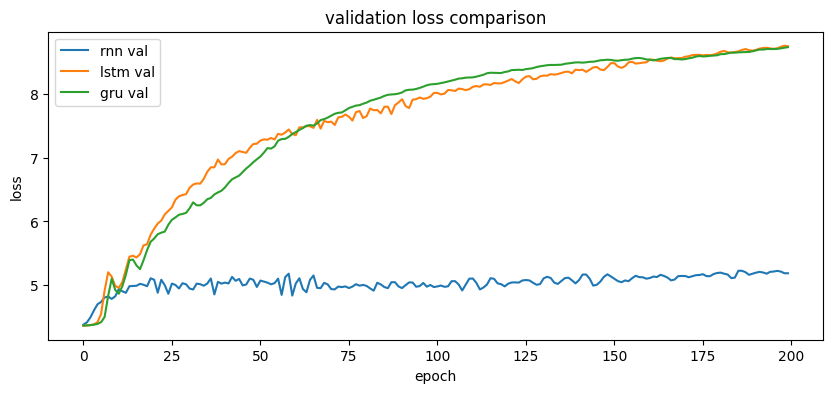

In [8]:
plt.figure(figsize=(10, 4))
plt.plot(rnn_history.history["loss"], label="rnn train")
plt.plot(lstm_history.history["loss"], label="lstm train")
plt.plot(gru_history.history["loss"], label="gru train")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("training loss comparison")
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(rnn_history.history["val_loss"], label="rnn val")
plt.plot(lstm_history.history["val_loss"], label="lstm val")
plt.plot(gru_history.history["val_loss"], label="gru val")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("validation loss comparison")
plt.legend()
plt.show()

## Text Generation Function
This function predicts the next word again and again to build a full sentence. Temperature controls how random the word choice is.

In [9]:
def generate_text(model, seed_text, next_words=8):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding="pre")
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]
        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## Generate Text Samples
Same seed text is passed to all three models to compare the quality of generated sentences.

In [12]:
seed = "neural networks are used for"

print("rnn :", generate_text(rnn_model, seed, next_words=10))
print("lstm:", generate_text(lstm_model, seed, next_words=10))
print("gru :", generate_text(gru_model, seed, next_words=10))

rnn : neural networks are used for the data has some order like text little train one
lstm: neural networks are used for when the data has some order like text text text
gru : neural networks are used for the data has some order like like text text text


## Learning Tasks
1. Replace the corpus with a longer paragraph of your own
2. Increase the embedding dimension from 32 to 64
3. Change hidden units from 64 to 128 and check if loss improves
4. Try different temperature values in generate_text
5. Compare param count vs training time for all three models

## Conclusion
- vanilla rnn trains fastest but has the highest validation loss because it struggles with longer context
- lstm has the most parameters and generally gets the lowest loss on this corpus
- gru gets close to lstm performance with fewer parameters, so it trains a bit faster
- validation loss is what actually shows generalization, training loss alone can be misleading

- with only 90 training samples and 200 epochs, all three models overfit heavily
  training loss drops close to zero while validation loss climbs back up
- this is visible in the loss curves where the val loss and train loss diverge after 
  a certain point
- the repeated words in generated output like "text text text" are a direct result 
  of overfitting the model gets stuck on the highest probability word it memorized
- a larger corpus or an earlystopping callback would reduce overfitting and produce 
  more coherent generated text